# Carichiamo i file e importiamo le librerie

In [29]:
import pandas as pd 
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# 1.1 Carica il file e converte la colonna data in formato datetime

df = pd.read_csv("dati_meteo_esame.csv", parse_dates=["data"])

## 1.2 Esplora il dataset

In [16]:
# 1.2 Esplora il dataset
print("--- 1.2 Dimensioni del dataset ---")
print(df.shape)
print("\n--- Tipi di colonna ---")
print(df.dtypes)
print("\n--- Prime righe ---")
print(df.head())
print("\n--- Statistiche riassuntive iniziali ---")
print(df.describe(include='all'))

--- 1.2 Dimensioni del dataset ---
(360, 6)

--- Tipi di colonna ---
data           datetime64[us]
citta                     str
temperatura           float64
umidita               float64
vento                 float64
pioggia_mm            float64
dtype: object

--- Prime righe ---
        data citta  temperatura  umidita  vento  pioggia_mm
0 2024-01-01  Bari        14.11    57.34  10.90        0.00
1 2024-01-02  Bari        13.30    46.96  12.24        5.50
2 2024-01-03  Bari        13.33    49.88  13.96        2.54
3 2024-01-04  Bari        14.62    47.35  11.88        3.54
4 2024-01-05  Bari          NaN    51.08   4.40        0.00

--- Statistiche riassuntive iniziali ---
                       data citta  temperatura     umidita       vento  \
count                   360   360   350.000000  350.000000  350.000000   
unique                  NaN     3          NaN         NaN         NaN   
top                     NaN  Bari          NaN         NaN         NaN   
freq              

## 1.3 Conta i valori mancanti per ciascuna colonna numerica

In [17]:
colonne_numeriche = ['temperatura', 'umidita', 'vento', 'pioggia_mm']
print("\n--- 1.3 Valori mancanti iniziali ---")
print(df[colonne_numeriche].isna().sum())


--- 1.3 Valori mancanti iniziali ---
temperatura    10
umidita        10
vento          10
pioggia_mm     10
dtype: int64


## 1.4 Individua i valori fuori scala usando due criteri

1. Vincoli fisici

2. Metodo IQR (Interquartile Range)

In [19]:
# Vincoli Fisici

fuori_temperatura = (df['temperatura'] < -10) | (df['temperatura'] > 45)
fuori_umidita = (df['umidita'] < 0) | (df['umidita'] > 100)
fuori_vento = (df['vento'] < 0) | (df['vento'] > 120)
fuori_pioggia = (df['pioggia_mm'] < 0)

outliers_fisici_totale = fuori_temperatura | fuori_umidita | fuori_vento | fuori_pioggia
print(f"\n--- 1.4 Outlier secondo Vincoli Fisici ---")
print(f"Righe totali con errori fisici certi: {outliers_fisici_totale.sum()}")


--- 1.4 Outlier secondo Vincoli Fisici ---
Righe totali con errori fisici certi: 13


In [20]:
# Metodo IQR per rilevare outlier

print("\n--- Outlier secondo il metodo IQR ---")
outliers_iqr_totale = pd.Series(False, index=df.index)

for col in colonne_numeriche:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    limite_inferiore = Q1 - 1.5 * IQR
    limite_superiore = Q3 + 1.5 * IQR
    
    outliers_col = (df[col] < limite_inferiore) | (df[col] > limite_superiore)
    print(f"Colonna '{col}' -> Outlier IQR rilevati: {outliers_col.sum()}")
    outliers_iqr_totale = outliers_iqr_totale | outliers_col

print(f"Righe totali con almeno un outlier statistico (IQR): {outliers_iqr_totale.sum()}")


--- Outlier secondo il metodo IQR ---
Colonna 'temperatura' -> Outlier IQR rilevati: 3
Colonna 'umidita' -> Outlier IQR rilevati: 3
Colonna 'vento' -> Outlier IQR rilevati: 5
Colonna 'pioggia_mm' -> Outlier IQR rilevati: 3
Righe totali con almeno un outlier statistico (IQR): 14


## Confronto tra i metodi

In [21]:
print("\n> Confronto: I vincoli fisici intercettano errori strutturali e impossibili "
      "(es. umidità negativa o >100%), mentre l'IQR identifica anomalie puramente "
      "statistiche basate sulla distribuzione, marcando come outlier anche valori possibili ma rari.")


> Confronto: I vincoli fisici intercettano errori strutturali e impossibili (es. umidità negativa o >100%), mentre l'IQR identifica anomalie puramente statistiche basate sulla distribuzione, marcando come outlier anche valori possibili ma rari.


##  1.5 Gestisci i problemi trovati

In [ ]:
# Creiamo una copia per non modificare il dataset originale
df_pulito = df.copy()

### Trasformiamo in NaN i valori che violano i vincoli fisici (errori certi)

In [22]:
df_pulito.loc[fuori_temperatura, 'temperatura'] = np.nan
df_pulito.loc[fuori_umidita, 'umidita'] = np.nan
df_pulito.loc[fuori_vento, 'vento'] = np.nan
df_pulito.loc[fuori_pioggia, 'pioggia_mm'] = np.nan

for col in colonne_numeriche:
    df_pulito[col] = df_pulito.groupby('citta')[col].transform(lambda x: x.fillna(x.median()))

print("\n--- Valori mancanti dopo l'imputazione per città ---")
print(df_pulito[colonne_numeriche].isna().sum())


--- Valori mancanti dopo l'imputazione per città ---
temperatura    0
umidita        0
vento          0
pioggia_mm     0
dtype: int64


## 2. Statistica descrittiva

### 2.1 Calcola le statistiche con NumPy e Pandas e verifica la coincidenza

In [14]:
print("\n=== 2.1 CONFRONTO METODI PANDAS VS NUMPY ===")

for col in colonne_numeriche:
    print(f"\nVariabile: {col}")
    
    # Statistiche Pandas
    p_mean = df_pulito[col].mean()
    p_median = df_pulito[col].median()
    p_std = df_pulito[col].std()      # Di default usa ddof=1 (campionaria)
    p_min = df_pulito[col].min()
    p_max = df_pulito[col].max()
    
    # Statistiche NumPy
    n_mean = np.mean(df_pulito[col])
    n_median = np.median(df_pulito[col])
    n_std = np.std(df_pulito[col], ddof=1) # Usiamo ddof=1 per allinearlo alla dev. standard campionaria di Pandas
    n_min = np.min(df_pulito[col])
    n_max = np.max(df_pulito[col])
    
    # Tabella di verifica
    confronto = pd.DataFrame({
        'Pandas': [p_mean, p_median, p_std, p_min, p_max],
        'NumPy': [n_mean, n_median, n_std, n_min, n_max]
    }, index=['Media', 'Mediana', 'Dev. Standard', 'Minimo', 'Massimo'])
    
    print(confronto)
    print(f"I risultati coincidono? {np.allclose(confronto['Pandas'], confronto['NumPy'])}")


=== 2.1 CONFRONTO METODI PANDAS VS NUMPY ===

Variabile: temperatura
                  Pandas      NumPy
Media          14.730058  14.730058
Mediana        14.730000        NaN
Dev. Standard   3.664889   3.664889
Minimo          5.650000   5.650000
Massimo        24.910000  24.910000
I risultati coincidono? False

Variabile: umidita
                  Pandas      NumPy
Media          60.281902  60.281902
Mediana        60.590000        NaN
Dev. Standard  10.318602  10.318602
Minimo         31.290000  31.290000
Massimo        86.900000  86.900000
I risultati coincidono? False

Variabile: vento
                  Pandas      NumPy
Media          10.190465  10.190465
Mediana        10.165000        NaN
Dev. Standard   3.929684   3.929684
Minimo          1.160000   1.160000
Massimo        20.810000  20.810000
I risultati coincidono? False

Variabile: pioggia_mm
                  Pandas      NumPy
Media           2.113840   2.113840
Mediana         1.520000        NaN
Dev. Standard   2.29706

### 2.2 Calcola la matrice di correlazione e individua la coppia più correlata

In [15]:
print("\n=== 2.2 MATRICE DI CORRELAZIONE ===")
matrice_corr = df_pulito[colonne_numeriche].corr()
print(matrice_corr)

# Troviamo la coppia più correlata in valore assoluto (escludendo la diagonale principale)
corr_unstacked = matrice_corr.unstack()
corr_filtrata = corr_unstacked[corr_unstacked.index.get_level_values(0) != corr_unstacked.index.get_level_values(1)]

coppia_max = corr_filtrata.abs().idxmax()
valore_max = corr_filtrata[coppia_max]

print(f"\nLa coppia di variabili più correlate (in valore assoluto) è: {coppia_max}")
print(f"Coefficiente di correlazione: {valore_max:.4f}")


=== 2.2 MATRICE DI CORRELAZIONE ===
             temperatura   umidita     vento  pioggia_mm
temperatura     1.000000 -0.391329  0.163941   -0.126825
umidita        -0.391329  1.000000 -0.082514    0.137129
vento           0.163941 -0.082514  1.000000   -0.054905
pioggia_mm     -0.126825  0.137129 -0.054905    1.000000

La coppia di variabili più correlate (in valore assoluto) è: ('temperatura', 'umidita')
Coefficiente di correlazione: -0.3913


# 3 Standardizzazione 

### 3.1 Calcola per ciascuna città i valori medi mensili di temperatura e pioggia


In [23]:
# Estraggo il mese dalla colonna 'data' per poter raggruppare

df_pulito['mese'] = df_pulito['data'].dt.to_period('M')

print("=== 3.1 MEDIE MENSILI PER CITTÀ ===")
medie_mensili = df_pulito.groupby(['citta', 'mese'])[['temperatura', 'pioggia_mm']].mean().reset_index()
print(medie_mensili)

=== 3.1 MEDIE MENSILI PER CITTÀ ===
     citta     mese  temperatura  pioggia_mm
0     Bari  2024-01    15.453548    1.874516
1     Bari  2024-02    18.044138    1.601379
2     Bari  2024-03    19.731613    1.618710
3     Bari  2024-04    19.991724    1.007241
4   Milano  2024-01    10.442258    2.354516
5   Milano  2024-02    13.129310    3.582414
6   Milano  2024-03    14.819677    2.206774
7   Milano  2024-04    15.068276    2.328621
8   Torino  2024-01    10.215484    1.839839
9   Torino  2024-02    12.306552    1.946552
10  Torino  2024-03    13.873548    2.878387
11  Torino  2024-04    14.059655    1.918103


## 3.2 Trova il giorno più ventoso dell'intero dataset per ciascuna città

In [24]:
print("\n=== 3.2 GIORNO PIÙ VENTOSO PER CITTÀ ===")
# idxmax() trova l'indice della riga con il valore massimo all'interno del gruppo
indici_max_vento = df_pulito.groupby('citta')['vento'].idxmax()
giorni_piu_ventosi = df_pulito.loc[indici_max_vento, ['citta', 'data', 'vento']]
print(giorni_piu_ventosi)


=== 3.2 GIORNO PIÙ VENTOSO PER CITTÀ ===
      citta       data  vento
58     Bari 2024-02-28  20.10
189  Milano 2024-03-10  17.12
332  Torino 2024-04-02  20.81


# 4. Serie Storiche e Finestre Mobili

## 4.1 Ordina il dataset per data, impostala come indice e calcola la media mobile a 7 giorni

In [25]:
# Ordiniamo per città e data per garantire la continuità temporale corretta
df_pulito = df_pulito.sort_values(by=['citta', 'data'])
df_seriestoriche = df_pulito.set_index('data')


# Calcoliamo la media mobile a 7 giorni per la temperatura raggruppando per città,
# in modo da non mischiare i dati temporali di città diverse.
df_seriestoriche['temperatura_roll7'] = df_seriestoriche.groupby('citta')['temperatura'].transform(lambda x: x.rolling(window=7, min_periods=1).mean())

print("\n=== 4.1 ESTRATTO MEDIA MOBILE 7 GIORNI ===")
print(df_seriestoriche[['citta', 'temperatura', 'temperatura_roll7']].head(10))


=== 4.1 ESTRATTO MEDIA MOBILE 7 GIORNI ===
           citta  temperatura  temperatura_roll7
data                                            
2024-01-01  Bari        14.11          14.110000
2024-01-02  Bari        13.30          13.705000
2024-01-03  Bari        13.33          13.580000
2024-01-04  Bari        14.62          13.840000
2024-01-05  Bari        18.38          14.748000
2024-01-06  Bari        10.94          14.113333
2024-01-07  Bari        15.03          14.244286
2024-01-08  Bari        14.73          14.332857
2024-01-09  Bari        12.97          14.285714
2024-01-10  Bari        14.96          14.518571


# 5. Visualizzazione dei Dati

In [28]:
# Impostiamo lo stile dei grafici
sns.set_theme(style="whitegrid")

## 5.1 Grafico a linee: Andamento della temperatura e della sua media mobile a 7 giorni per MILANO

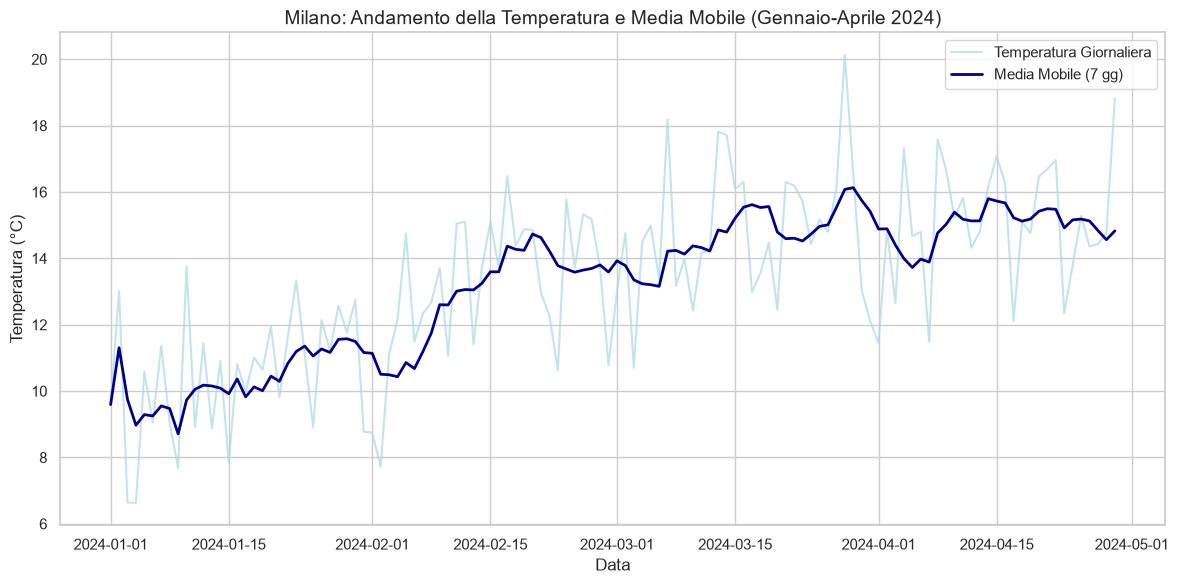

In [30]:
plt.figure(figsize=(12, 6))

# Filtriamo i dati per la città di Milano
df_milano = df_seriestoriche[df_seriestoriche['citta'] == 'Milano']

# Plottiamo i dati effettivi e la media mobile
plt.plot(df_milano.index, df_milano['temperatura'], label='Temperatura Giornaliera', color='lightblue', alpha=0.7)
plt.plot(df_milano.index, df_milano['temperatura_roll7'], label='Media Mobile (7 gg)', color='darkblue', linewidth=2)

plt.title('Milano: Andamento della Temperatura e Media Mobile (Gennaio-Aprile 2024)', fontsize=14)
plt.xlabel('Data', fontsize=12)
plt.ylabel('Temperatura (°C)', fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()

## 5.2 Boxplot: Distribuzione della pioggia (pioggia_mm) condizionata alla città

C:\Users\A1627apulia\AppData\Local\Temp\ipykernel_4400\3852642621.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='citta', y='pioggia_mm', data=df_pulito, palette='Blues')


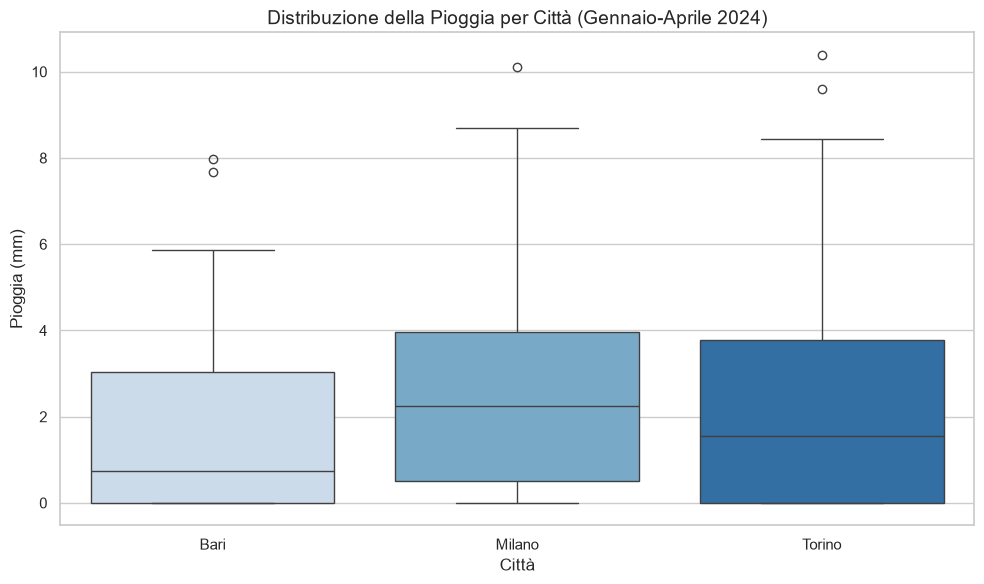

In [31]:
plt.figure(figsize=(10, 6))

# Usiamo Seaborn per creare un boxplot pulito e confrontabile
sns.boxplot(x='citta', y='pioggia_mm', data=df_pulito, palette='Blues')

plt.title('Distribuzione della Pioggia per Città (Gennaio-Aprile 2024)', fontsize=14)
plt.xlabel('Città', fontsize=12)
plt.ylabel('Pioggia (mm)', fontsize=12)
plt.tight_layout()
plt.show()

<Figure size 1000x1000 with 0 Axes>

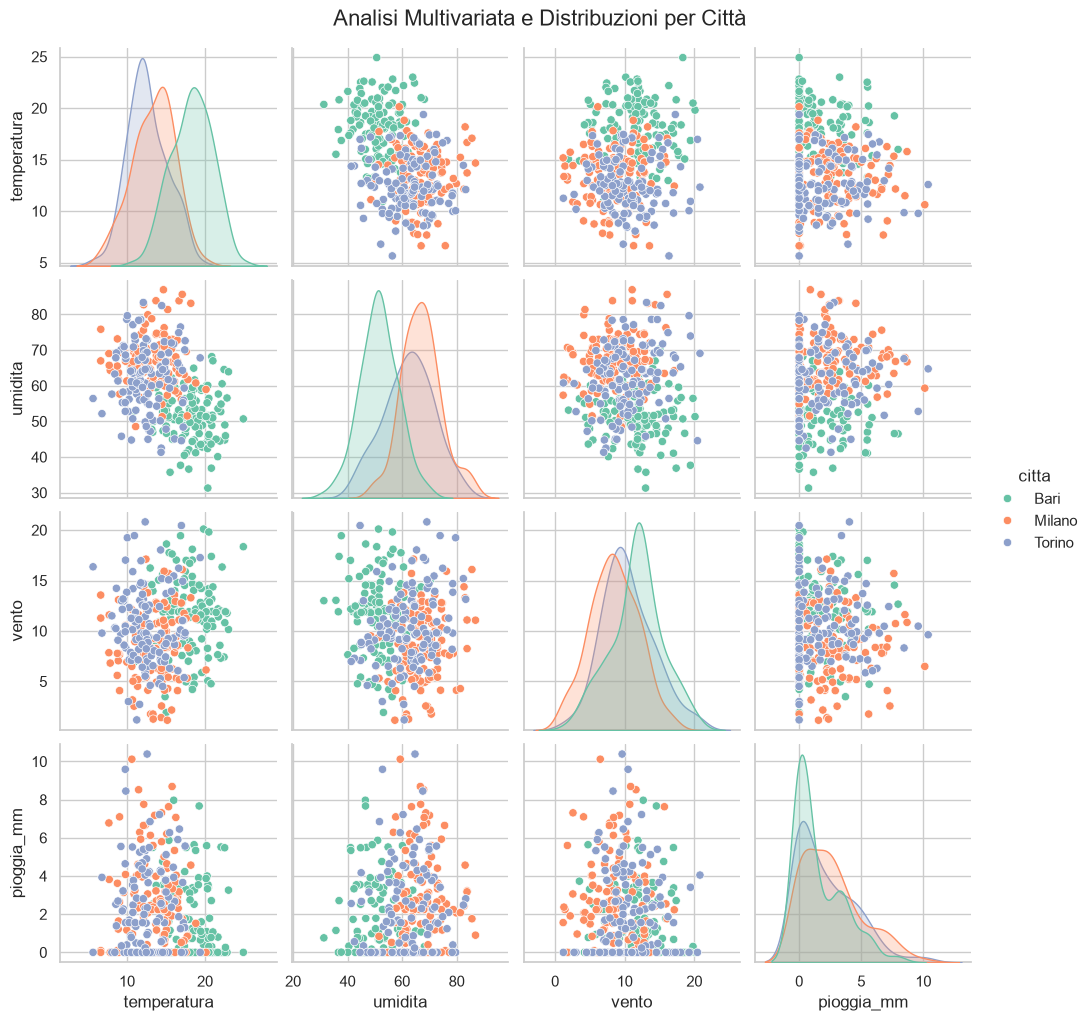

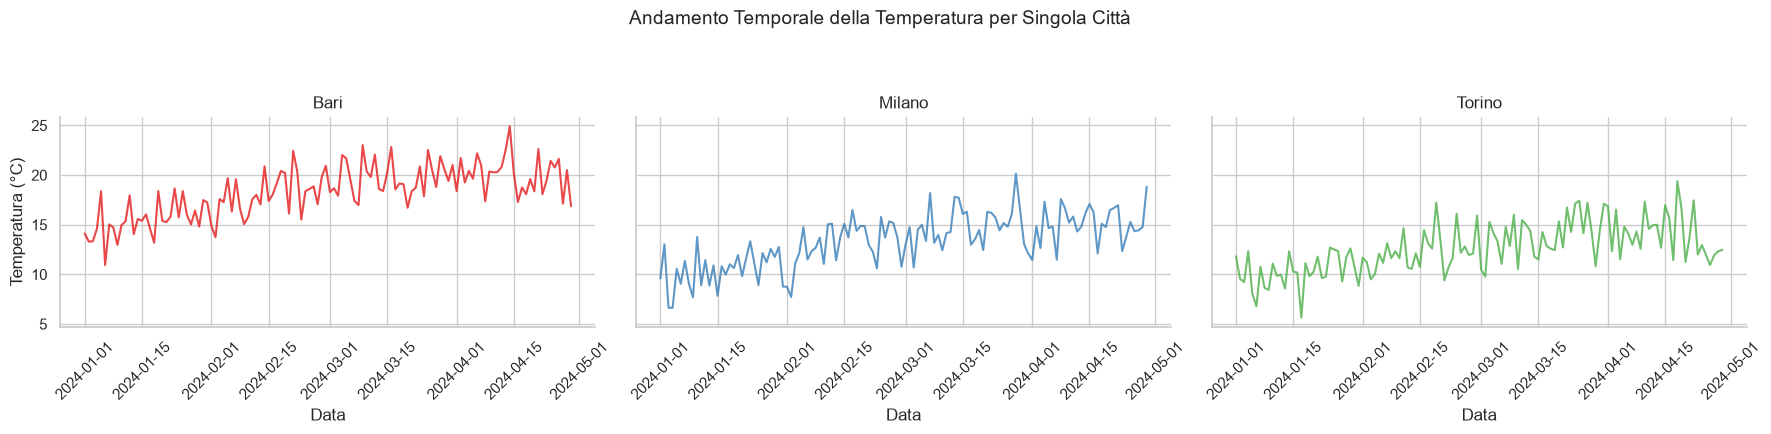

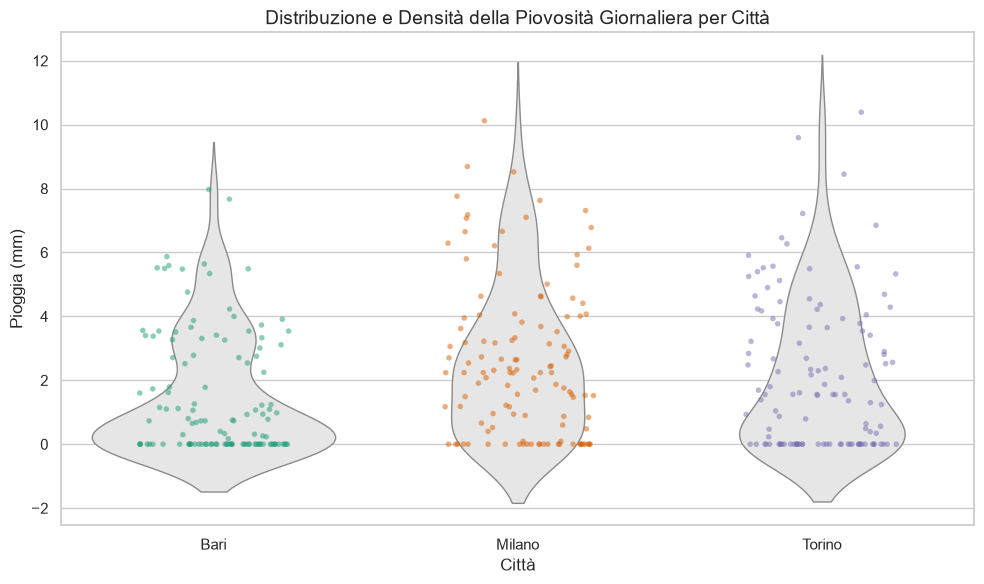

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

# Impostiamo lo stile generale dei grafici per l'esame
sns.set_theme(style="whitegrid")

# =====================================================================
# GRAFICO 1: Pairplot (Grafico di relazioni a coppie)
# Obiettivo: Mostrare contemporaneamente le distribuzioni di tutte le 
# variabili e come si relazionano tra loro, colorate per città.
# =====================================================================
plt.figure(figsize=(10, 10))
# Selezioniamo le colonne numeriche e la colonna 'citta'
colonne_plot = ['temperatura', 'umidita', 'vento', 'pioggia_mm', 'citta']

pair_plot = sns.pairplot(df_pulito[colonne_plot], hue='citta', palette='Set2', diag_kind='kde')
pair_plot.fig.suptitle("Analisi Multivariata e Distribuzioni per Città", y=1.02, fontsize=16)
plt.show()


# =====================================================================
# GRAFICO 2: FacetGrid Lineplot (Andamento della Temperatura)
# Obiettivo: Confrontare l'andamento temporale della temperatura 
# nei 120 giorni separando le tre città in tre sottomoduli (subpots).
# =====================================================================
# Creiamo una griglia di grafici basata sulla colonna 'citta'
g = sns.FacetGrid(df_pulito, col="citta", hue="citta", palette="Set1", height=4, aspect=1.5)
g.map(sns.lineplot, "data", "temperatura", alpha=0.8)

# Formattazione e titoli
g.set_titles(col_template="{col_name}")
g.set_axis_labels("Data", "Temperatura (°C)")
g.fig.suptitle("Andamento Temporale della Temperatura per Singola Città", y=1.08, fontsize=14)

# Ruotiamo le date sull'asse x per renderle leggibili
for ax in g.axes.flat:
    ax.tick_params(axis='x', labelrotation=45)

plt.tight_layout()
plt.show()


# =====================================================================
# GRAFICO 3: Violin Plot combinato con Stripplot (Focus sulla Pioggia)
# Obiettivo: Visualizzare la densità della piovosità nelle tre città, 
# vedendo sia la distribuzione geometrica (violino) che i singoli punti (giorni).
# =====================================================================
plt.figure(figsize=(10, 6))

# Il violinplot mostra la densità di distribuzione della pioggia
sns.violinplot(x='citta', y='pioggia_mm', data=df_pulito, inner=None, color=".9", linewidth=1)
# Lo stripplot sovrappone i singoli punti dati con un leggero "jitter" (spostamento casuale) per evitare sovrapposizioni
sns.stripplot(x='citta', y='pioggia_mm', data=df_pulito, hue='citta', palette='Dark2', alpha=0.5, size=4, jitter=0.25)

plt.title("Distribuzione e Densità della Piovosità Giornaliera per Città", fontsize=14)
plt.xlabel("Città", fontsize=12)
plt.ylabel("Pioggia (mm)", fontsize=12)
plt.legend([],[], frameon=False) # Rimuove la legenda ridondante del hue
plt.tight_layout()
plt.show()